In [1]:
from d2l import torch as d2l
import torch

In [2]:
class Classifier(d2l.Module):
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('accuracy', self.accuracy(Y_hat, batch[-1]), train=False)

    def accuracy(self, Y_hat, Y, average=True):
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        preds = Y_hat.argmax(axis=1).type(Y.dtype)
        compare = (preds == Y.reshape(-1)).type(torch.float32)
        return compare.mean() if average else compare

In [3]:
@d2l.add_to_class(d2l.Module) #@save
def configure_optimizer(self):
    return torch.optim.SGD(self.parameters(), lr=self.lr)

In [4]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(axis=1, keepdim=True)
    return X_exp / partition

In [5]:
X = torch.rand(2, 5)
X_prob = softmax(X)
X_prob, X_prob.sum(axis=1)

(tensor([[0.2286, 0.1992, 0.1678, 0.1680, 0.2365],
         [0.2392, 0.2458, 0.1862, 0.1479, 0.1809]]),
 tensor([1.0000, 1.0000]))

In [6]:
class SoftmaxRegressionFromScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr=0.1, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]
    
    def forward(self, X):
        X = X.reshape((-1, self.W.shape[0]))
        linear = torch.matmul(X, self.W) + self.b
        return softmax(linear)
    

In [7]:
def cross_entropy(Y_hat, y):
    return -torch.log(Y_hat[list(range(len(Y_hat))), y]).mean()

In [8]:
Y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y = torch.tensor([0, 2])
cross_entropy(Y_hat, y)


tensor(1.4979)

In [9]:
@d2l.add_to_class(SoftmaxRegressionFromScratch) #@save
def loss(self, Y_hat, y):
    return cross_entropy(Y_hat, y)

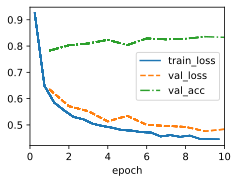

In [10]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionFromScratch(num_inputs=784, num_outputs=10)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [11]:
X, y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([256])

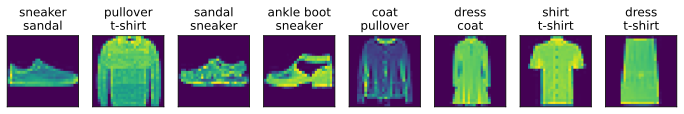

In [12]:
wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)

In [13]:
#Current implementation of softmax causes overflow for large value of input
X = torch.tensor([[0, 1 , 2, 3, 100]])
softmax(X)

tensor([[0., 0., 0., 0., nan]])

In [14]:
X = torch.tensor([[0, 1 , 2, 3, 100]])
X_rel = X - torch.max(X, axis=1)[0]
softmax(X_rel)

tensor([[3.7835e-44, 1.0089e-43, 2.7465e-43, 7.4689e-43, 1.0000e+00]])

In [15]:
X = torch.tensor([[0, 1 , 2, 3, 4]])
X_rel = X - torch.max(X, axis=1)[0]
print(f"softmax(X) : {softmax(X)} \nsoftmax(X_rel) : {softmax(X_rel)}")

softmax(X) : tensor([[0.0117, 0.0317, 0.0861, 0.2341, 0.6364]]) 
softmax(X_rel) : tensor([[0.0117, 0.0317, 0.0861, 0.2341, 0.6364]])


In [16]:
import torch.nn.functional as F

class SoftmaxRegressionFromScratchTest(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr=0.1, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]
    
    def forward(self, X):
        X = X.reshape((-1, self.W.shape[0]))
        linear = torch.matmul(X, self.W) + self.b
        return softmax(linear)
    def cross_entropy(self, Y_hat, y):
        y_one_hot = F.one_hot(y, num_classes=self.num_outputs, dtype=torch.float32)
        return -torch.log(Y_hat*y_one_hot).mean()

    def loss(self, Y_hat, y):
        return cross_entropy(Y_hat, y)

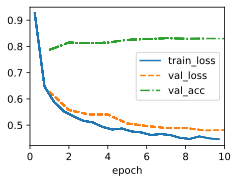

In [17]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionFromScratchTest(num_inputs=784, num_outputs=10)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)


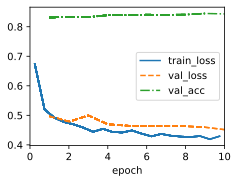

In [18]:
data = d2l.FashionMNIST(batch_size=32)
model = SoftmaxRegressionFromScratch(num_inputs=784, num_outputs=10)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

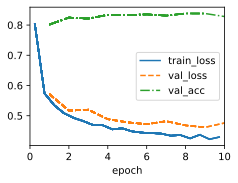

In [19]:
data = d2l.FashionMNIST(batch_size=128)
model = SoftmaxRegressionFromScratch(num_inputs=784, num_outputs=10)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

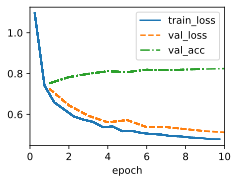

In [20]:
#Increasing the batch size reduced the model performace. To compansate for this we can try adjusting the learning rate

data = d2l.FashionMNIST(batch_size=512)
model = SoftmaxRegressionFromScratch(num_inputs=784, num_outputs=10)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

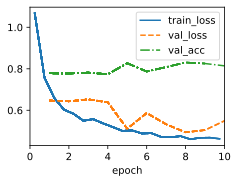

In [21]:
data = d2l.FashionMNIST(batch_size=512)
model = SoftmaxRegressionFromScratch(num_inputs=784, num_outputs=10, lr=0.2)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)





 
How adjusting learning rate can improve model performace for large batch size

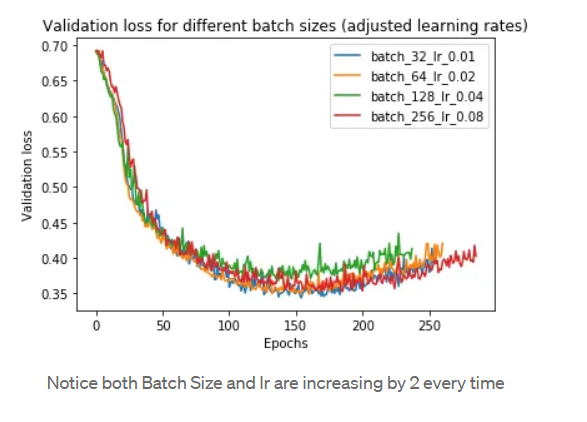

Larger batch size -> Weak generalization but this can be fixed using adaptive training.

Training a model with large batch size with same accuracy/performace for model with small batch size can be useful as it can
cut down the training time as we need to update parameters few times.

We double the batch size then the number of times the parameters are updated is halved. Moreover since the number of batches
decreases we increase batch size, the overhead of moving batch from CPU to GPU also decreases. This can also help in reducing training time.
However the tradeoff with using large batch size is that we start missing out the advantages of stochastic gradient descent.

Larger batch size -> fewer updated + shifting data -> lower computational cost

In [22]:
#Concise implementation of softmax regression
import torch.nn as nn

class SoftmaxRegression(d2l.Classifier):
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(out_features=num_outputs))
    def forward(self, X):
        return self.net(X)

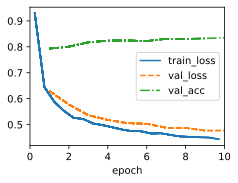

In [23]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegression(num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [24]:
x = torch.arange(0, -200, -1)
smallest = x[0]

for i in range(0, len(x)):
    y = torch.exp(x[i])
    if y == 0.0:
        smallest = x[i]
        break
print(f"Underflow point: {smallest}")

Underflow point: -104


In [25]:
x = torch.arange(0, 200, 1)
smallest = x[0]

for i in range(0, len(x)):
    y = torch.exp(x[i])
    if y == torch.inf:
        smallest = x[i]
        break
print(f"Overflow point: {smallest}")

Overflow point: 89


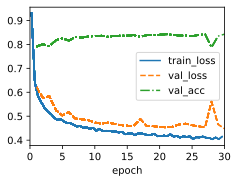

In [26]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegression(num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=30)
trainer.fit(model, data)

In [27]:
Y_hat = torch.tensor([[[[1, 2 ,3, 4],[5, 6, 7, 8]], [[9, 10, 11, 12], [13, 14, 15, 16]]]])
Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
Y_hat

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

In [28]:
data = d2l.FashionMNIST(batch_size=256)
lrs = [0.001,0.01,0.03,0.1,0.3,1]
train_loss, valid_loss = [],[]
for lr in lrs:
    model = SoftmaxRegression(num_outputs=10, lr=lr)
    trainer = d2l.Trainer(max_epochs=10, plot_flag=False)
    temp = trainer.fit(model, data)
    train_loss.append(temp[0])
    valid_loss.append(temp[1])

TypeError: Trainer.__init__() got an unexpected keyword argument 'plot_flag'

In [ ]:
class CustomClassifier(d2l.Classifier):
    def __init__(self, plot_graph=True):
        super().__init__()
        self.save_hyperparameters()
        self.plot_graph = plot_graph
        self.val_loss_per_epoch = []
        self.val_accuracy_per_epoch = []
        self.training_loss_per_epoch = []

    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        loss = self.loss(Y_hat, batch[-1])
        acc = self.accuracy(Y_hat, batch[-1])
        self.val_loss_per_epoch.append(loss)
        self.val_accuracy_per_epoch.append(acc)
        if self.plot_graph:
            self.plot('loss', loss, train=False)
            self.plot('acc', acc, train=False)
        return
    
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.training_loss_per_epoch.append(l)
        if self.plot_graph:
            self.plot('loss', l, train=True)
        return l

In [ ]:
class SoftmaxRegression(CustomClassifier):
    def __init__(self, num_outputs, lr, plot_graph=True):
        super().__init__(plot_graph=plot_graph)
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(out_features=num_outputs))
    def forward(self, X):
        return self.net(X)

In [ ]:
data = d2l.FashionMNIST(batch_size=256)
lrs = [0.001,0.01,0.03,0.1,0.3,1]
train_loss, valid_loss = [], []

for lr in lrs:
    model = SoftmaxRegression(num_outputs=10, lr=lr, plot_graph=False)
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)
    train_loss.append(model.training_loss_per_epoch)
    valid_loss.append(model.val_loss_per_epoch)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

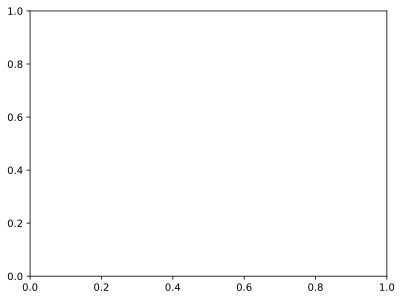

In [ ]:
#Plot losses using mathplotlib
import matplotlib.pyplot as plt
plt.plot(lrs, train_loss)
plt.plot(lrs, valid_loss)
plt.legend(['Train loss', 'Validation loss'])
plt.xlabel('Learning rate')
plt.ylabel('Loss')
plt.show()